# Phase 5 (notebook 05) — first XGBoost with GroupKFold CV

Everything from 04 is in place: cached features (`train_features.pkl`, `test_features.pkl`), 5-fold
GroupKFold assignments attached as `train_feats['fold']`, leakage assertions all green, test row count
matches `sample_submission`. Time to train.

**Design decisions:**
- **Target = residual.** Predict `target_tvt − anchor_tvt`, then add `anchor_tvt` back at inference time.
  This way a model that learns nothing useful predicts ~0 and degrades gracefully to baseline A.
- **5-fold GroupKFold by well.** Folds attached in 04. Each fold's val set is held-out wells the model
  never sees during training — honest cross-well generalization.
- **Conservative XGBoost.** `max_depth=6, lr=0.05, n_estimators=2000` with early stopping on val RMSE.
  Standard regularization (subsample=0.8, colsample=0.8, min_child_weight=10).
- **Fold ensemble for test predictions.** Mean of 5 fold models, each trained on 4/5 of the data.

**Sections:**
- §0 Setup
- §1 Load features + zero-residual sanity check (must reproduce A's 15.91)
- §2 Train 5-fold XGBoost, accumulate OOF predictions
- §3 OOF analysis — pooled RMSE, per-fold breakdown, per-well A-vs-XGB comparison
- §4 Feature importance — does the model use anything beyond anchor signals?
- §5 Predict on test (fold ensemble), write submission if XGB beats A
- §6 Findings + next steps

## 0. Setup

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

ROOT = Path('..').resolve()
DATA = ROOT / 'data'
TRAIN_DIR = DATA / 'train'
TEST_DIR  = DATA / 'test'
CACHE_DIR = ROOT / 'cache';        CACHE_DIR.mkdir(exist_ok=True)
SUB_DIR   = ROOT / 'submissions';  SUB_DIR.mkdir(exist_ok=True)

try:
    import xgboost as xgb
    print(f'xgboost {xgb.__version__}')
except ImportError:
    raise ImportError('xgboost not installed. Run: pip install xgboost')

xgboost 3.2.0


## 1. Load features + zero-residual sanity check

Load the cached features. Compute the residual target. Then verify that **predicting 0 residual everywhere**
gives pooled RMSE = 15.91 — exactly baseline A. If this number is off, there's a bug somewhere upstream
(featurizer, anchor computation, or fold assignment) and we need to fix it before training a model.

In [2]:
train_feats = pd.read_pickle(CACHE_DIR / 'train_features.pkl')
test_feats  = pd.read_pickle(CACHE_DIR / 'test_features.pkl')
print(f'train: {train_feats.shape}  test: {test_feats.shape}')

# Define feature set: everything except identifiers, target, fold
NON_FEATURES = ['well', 'row_idx', 'target_tvt', 'fold']
FEATURE_COLS = [c for c in train_feats.columns if c not in NON_FEATURES]
print(f'\nFeatures ({len(FEATURE_COLS)}):')
for c in FEATURE_COLS: print(f'  {c}')

# Residual target: target_tvt - anchor_tvt
y_residual = (train_feats['target_tvt'] - train_feats['anchor_tvt']).astype('float64').values
print(f'\nResidual stats: mean={y_residual.mean():.3f}  std={y_residual.std():.3f}  '
      f'min={y_residual.min():.2f}  max={y_residual.max():.2f}')

# Sanity: predict 0 residual -> pooled RMSE = sqrt(mean(residual^2)). Should be 15.910.
rmse_zero = float(np.sqrt(np.mean(y_residual ** 2)))
print(f'\nSanity check (predict 0 residual): pooled RMSE = {rmse_zero:.3f}')
print(f'Expected (baseline A from 02/03/04):           15.910')
assert abs(rmse_zero - 15.910) < 0.01, f'sanity check failed: {rmse_zero:.3f} != 15.910'
print('OK — residual formulation is consistent with A.')

train: (3783989, 22)  test: (14151, 21)

Features (19):
  md
  x
  y
  z
  gr
  gr_local_mean_50
  gr_local_std_50
  anchor_tvt
  anchor_z
  anchor_md
  anchor_gr
  smooth_anchor_tvt_50
  slope_tvt_md_50
  d_md_from_anchor
  d_z_from_anchor
  d_gr_from_anchor
  gr_match_tvt
  gr_match_sim
  gr_match_delta_anchor

Residual stats: mean=1.596  std=15.830  min=-103.78  max=98.92

Sanity check (predict 0 residual): pooled RMSE = 15.910
Expected (baseline A from 02/03/04):           15.910
OK — residual formulation is consistent with A.


## 2. Train 5-fold XGBoost with OOF predictions

For each fold f ∈ {0..4}: train on the 4 non-`f` folds (≈ 3.0M rows from ≈ 618 wells), validate on fold
`f` (≈ 0.76M rows from ≈ 155 wells), early-stop when val RMSE plateaus. Store the model and the OOF
predictions on the val rows. After all 5 folds, every row in train_feats has exactly one OOF prediction —
an honest "if this row's well were unseen, what would the model predict?".

**Expect ~1–3 minutes per fold**, ~10–15 minutes total. The `tree_method='hist'` is the fast histogram
algorithm; without it this would take much longer on 3M rows.

In [5]:
N_FOLDS = 5
X_all = train_feats[FEATURE_COLS].astype('float32').values
y_all = y_residual.astype('float32')

from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=N_FOLDS)
fold_arr = np.full(len(train_feats), -1, dtype=np.int8)
for fold, (_, va_idx) in enumerate(gkf.split(train_feats, groups=train_feats['well'].values)):
    fold_arr[va_idx] = fold
assert (fold_arr >= 0).all(), 'some rows unassigned to any fold'
print(f'Fold sizes: {pd.Series(fold_arr).value_counts().sort_index().to_dict()}')

oof_preds = np.zeros(len(train_feats), dtype=np.float64)
fold_models = []
fold_rmses  = []
fold_iters  = []

for fold in range(N_FOLDS):
    tr_mask = fold_arr != fold
    va_mask = fold_arr == fold
    X_tr, y_tr = X_all[tr_mask], y_all[tr_mask]
    X_va, y_va = X_all[va_mask], y_all[va_mask]

    model = xgb.XGBRegressor(
        max_depth=6,
        learning_rate=0.05,
        n_estimators=2000,
        early_stopping_rounds=50,
        eval_metric='rmse',
        tree_method='hist',
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=42 + fold,
    )
    print(f'\n--- Fold {fold}: training on {len(y_tr):,} rows, validating on {len(y_va):,} rows ---')
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=200)

    pred_va = model.predict(X_va)
    oof_preds[va_mask] = pred_va
    rmse = float(np.sqrt(np.mean((pred_va - y_va) ** 2)))
    fold_models.append(model)
    fold_rmses.append(rmse)
    fold_iters.append(int(model.best_iteration))
    print(f'Fold {fold}: best_iter={model.best_iteration}, val RMSE={rmse:.3f}')

print(f'\n--- All folds done ---')
print(f'Per-fold val RMSEs: {[f"{r:.3f}" for r in fold_rmses]}')
print(f'Best iterations:    {fold_iters}')

Fold sizes: {0: 757738, 1: 756650, 2: 756255, 3: 757101, 4: 756245}

--- Fold 0: training on 3,026,251 rows, validating on 757,738 rows ---
[0]	validation_0-rmse:15.14916
[116]	validation_0-rmse:14.57174
Fold 0: best_iter=66, val RMSE=14.446

--- Fold 1: training on 3,027,339 rows, validating on 756,650 rows ---
[0]	validation_0-rmse:15.60986
[71]	validation_0-rmse:15.22151
Fold 1: best_iter=21, val RMSE=14.909

--- Fold 2: training on 3,027,734 rows, validating on 756,255 rows ---
[0]	validation_0-rmse:14.64039
[83]	validation_0-rmse:14.32020
Fold 2: best_iter=33, val RMSE=14.162

--- Fold 3: training on 3,026,888 rows, validating on 757,101 rows ---
[0]	validation_0-rmse:16.01590
[64]	validation_0-rmse:15.84992
Fold 3: best_iter=14, val RMSE=15.767

--- Fold 4: training on 3,027,744 rows, validating on 756,245 rows ---
[0]	validation_0-rmse:17.44614
[67]	validation_0-rmse:17.09884
Fold 4: best_iter=17, val RMSE=17.068

--- All folds done ---
Per-fold val RMSEs: ['14.446', '14.909', '

## 3. OOF analysis — pooled RMSE and per-well comparison

Pool the OOF predictions across all 5 folds, compute pooled RMSE — this is the headline number to compare
against A's 15.91. Then break down per-well: where does XGBoost win? Where does it lose? The expectation
from the §2/§3 audit in 04: XGB shouldn't lose much on the easy wells (target ≈ 0), and any pooled
improvement comes from getting the smooth-drifting wells (high `tvt_max_abs_dev`) closer to truth.

In [6]:
# Pooled OOF RMSE — directly comparable to A's 15.910 since residual_RMSE == TVT_RMSE (constant offset).
pooled_oof_rmse = float(np.sqrt(np.mean((oof_preds - y_all) ** 2)))
print(f'Pooled OOF RMSE:      {pooled_oof_rmse:.3f}')
print(f'Baseline A (carry-fwd):  15.910')
print(f'Delta:                {pooled_oof_rmse - 15.910:+.3f}')

# Per-fold pooled RMSE (over each fold's val rows)
print('\nPer-fold pooled RMSE on residual:')
for fold in range(N_FOLDS):
    m = fold_arr == fold
    rmse = float(np.sqrt(np.mean((oof_preds[m] - y_all[m]) ** 2)))
    a_rmse = float(np.sqrt(np.mean(y_all[m] ** 2)))
    print(f'  fold {fold}: XGB={rmse:.3f}   A={a_rmse:.3f}   delta={rmse - a_rmse:+.3f}')

Pooled OOF RMSE:      15.306
Baseline A (carry-fwd):  15.910
Delta:                -0.604

Per-fold pooled RMSE on residual:
  fold 0: XGB=14.446   A=15.290   delta=-0.844
  fold 1: XGB=14.909   A=15.917   delta=-1.009
  fold 2: XGB=14.162   A=14.678   delta=-0.516
  fold 3: XGB=15.767   A=16.047   delta=-0.280
  fold 4: XGB=17.068   A=17.480   delta=-0.412


In [7]:
# Per-well RMSEs for A and XGB, side by side
train_feats = train_feats.copy()
train_feats['oof_pred_residual'] = oof_preds
train_feats['squared_a_err']   = (train_feats['target_tvt'] - train_feats['anchor_tvt']) ** 2
train_feats['squared_xgb_err'] = (train_feats['oof_pred_residual'] - (train_feats['target_tvt'] - train_feats['anchor_tvt'])) ** 2

per_well = train_feats.groupby('well').agg(
    n_eval=('squared_a_err', 'count'),
    a_rmse=('squared_a_err',   lambda s: float(np.sqrt(s.mean()))),
    xgb_rmse=('squared_xgb_err', lambda s: float(np.sqrt(s.mean()))),
).reset_index()
per_well['delta'] = per_well['xgb_rmse'] - per_well['a_rmse']

n = len(per_well)
n_xgb_better = int((per_well['delta'] < 0).sum())
print(f'XGB better than A on {n_xgb_better}/{n} wells ({n_xgb_better/n*100:.1f}%)')
print(f'\nMedian per-well RMSE:  A={per_well["a_rmse"].median():.3f}   XGB={per_well["xgb_rmse"].median():.3f}')
print(f'Mean per-well RMSE:    A={per_well["a_rmse"].mean():.3f}   XGB={per_well["xgb_rmse"].mean():.3f}')
print(f'Max per-well RMSE:     A={per_well["a_rmse"].max():.3f}   XGB={per_well["xgb_rmse"].max():.3f}')

print('\nTop 5 wells where XGB beats A by the most:')
print(per_well.nsmallest(5, 'delta')[['well','n_eval','a_rmse','xgb_rmse','delta']].to_string(index=False))
print('\nTop 5 wells where XGB loses to A by the most:')
print(per_well.nlargest(5, 'delta')[['well','n_eval','a_rmse','xgb_rmse','delta']].to_string(index=False))

XGB better than A on 439/773 wells (56.8%)

Median per-well RMSE:  A=10.665   XGB=10.300
Mean per-well RMSE:    A=12.812   XGB=12.459
Max per-well RMSE:     A=70.639   XGB=67.911

Top 5 wells where XGB beats A by the most:
    well  n_eval    a_rmse  xgb_rmse      delta
1b1eba53    4655 70.639008 54.308452 -16.330556
fb03ae90    6431 42.887745 27.371535 -15.516209
15e154a1    6068 23.226074  7.865183 -15.360891
4c2208f5    5384 37.381435 24.359443 -13.021993
3f603129    5051 29.711920 18.112368 -11.599552

Top 5 wells where XGB loses to A by the most:
    well  n_eval    a_rmse  xgb_rmse     delta
27c3155b    4958 18.110415 34.464101 16.353686
a056d01e    6557  8.584208 22.397846 13.813638
c1708b88    6315 18.304607 30.775206 12.470599
96ae5806    9839  8.450897 18.464361 10.013464
a8ed028a    5538 19.044889 28.438158  9.393268


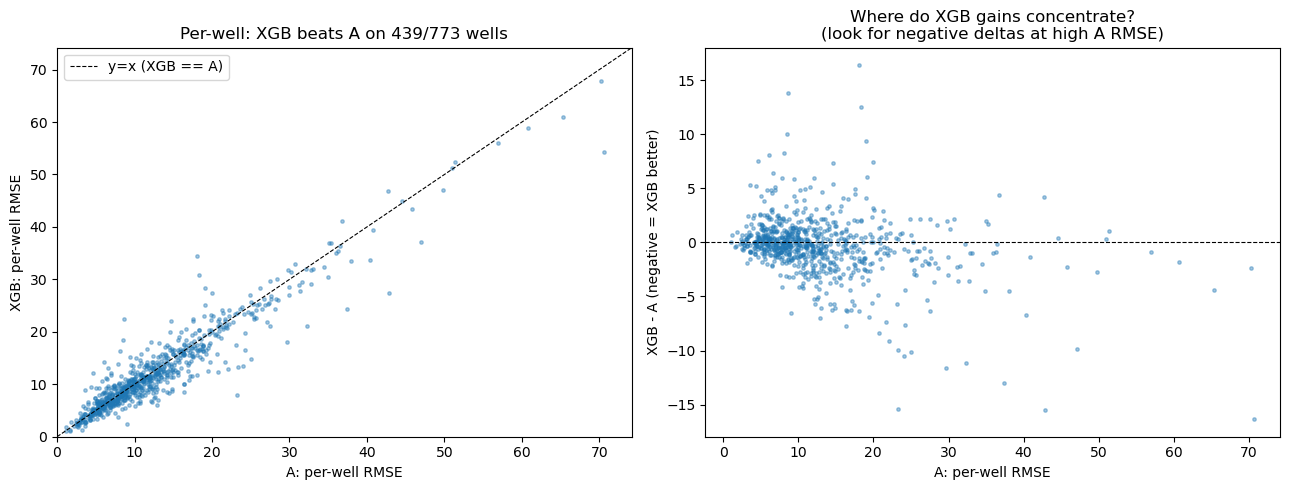

In [8]:
# Visual: head-to-head per-well RMSE, plus delta vs A's RMSE (does XGB win where it should?)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(per_well['a_rmse'], per_well['xgb_rmse'], s=6, alpha=0.4)
lim = max(per_well['a_rmse'].max(), per_well['xgb_rmse'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='y=x (XGB == A)')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('A: per-well RMSE'); ax.set_ylabel('XGB: per-well RMSE')
ax.set_title(f'Per-well: XGB beats A on {n_xgb_better}/{n} wells')
ax.legend()

ax = axes[1]
ax.scatter(per_well['a_rmse'], per_well['delta'], s=6, alpha=0.4)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('A: per-well RMSE')
ax.set_ylabel('XGB - A (negative = XGB better)')
ax.set_title('Where do XGB gains concentrate?\n(look for negative deltas at high A RMSE)')
plt.tight_layout(); plt.show()

## 4. Feature importance

Mean of XGBoost's `gain` importance across the 5 fold models. The interesting question: does the model
use anything beyond `anchor_tvt` and the trivially-related anchor features? If `gr_match_*`, `slope_tvt_md_50`,
or `d_md_from_anchor` show up high, that's evidence the GR-correlation work in 03 wasn't wasted — the model
found a way to use those features that hand-crafted methods couldn't.

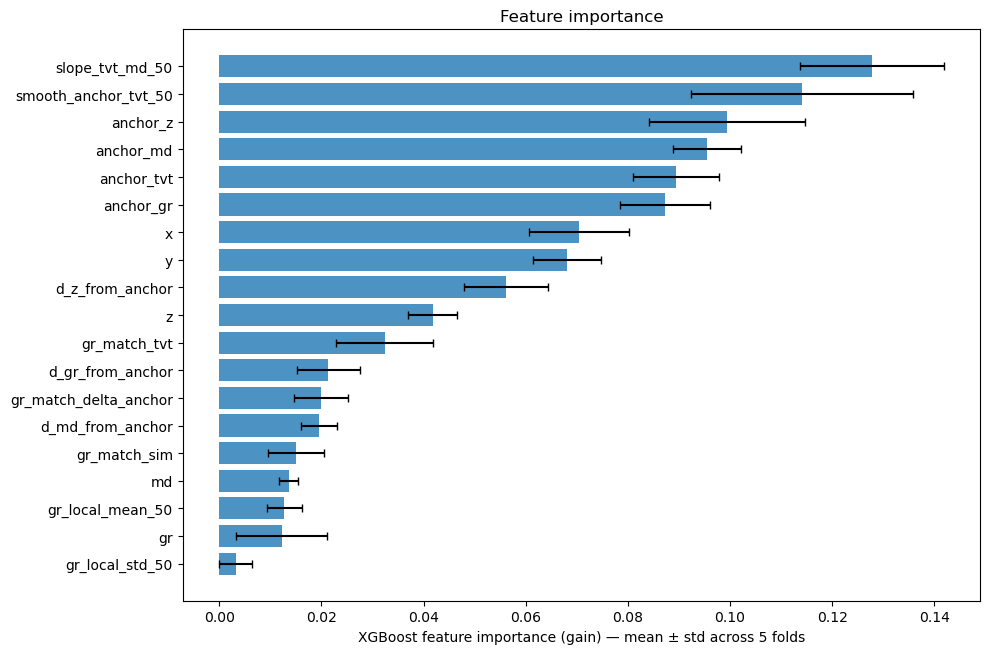


Top features by mean gain:
             feature     mean      std
     slope_tvt_md_50 0.127698 0.014117
smooth_anchor_tvt_50 0.114069 0.021727
            anchor_z 0.099460 0.015239
           anchor_md 0.095487 0.006736
          anchor_tvt 0.089424 0.008387
           anchor_gr 0.087274 0.008740
                   x 0.070441 0.009776
                   y 0.068130 0.006620
     d_z_from_anchor 0.056082 0.008239
                   z 0.041793 0.004741


In [9]:
imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    **{f'fold_{i}': fold_models[i].feature_importances_ for i in range(N_FOLDS)}
})
imp['mean'] = imp[[f'fold_{i}' for i in range(N_FOLDS)]].mean(axis=1)
imp['std']  = imp[[f'fold_{i}' for i in range(N_FOLDS)]].std(axis=1)
imp = imp.sort_values('mean', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(FEATURE_COLS))))
y_pos = np.arange(len(imp))[::-1]
ax.barh(y_pos, imp['mean'], xerr=imp['std'], capsize=3, alpha=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(imp['feature'])
ax.set_xlabel('XGBoost feature importance (gain) — mean ± std across 5 folds')
ax.set_title('Feature importance')
plt.tight_layout(); plt.show()

print('\nTop features by mean gain:')
print(imp[['feature','mean','std']].head(10).to_string(index=False))

## 5. Test predictions + submission

Predict on the 14,151 test rows using the 5-fold ensemble (mean of fold-model predictions). Add
`anchor_tvt` back to convert residual → absolute TVT. Map onto `sample_submission`'s row order via the
`{wellname}_{row_idx}` id. Only write the file if XGBoost beat A on OOF — otherwise A's submission from 02
remains the better choice and we shouldn't overwrite the leaderboard with worse predictions.

In [10]:
X_test = test_feats[FEATURE_COLS].astype('float32').values
test_residual_preds = np.mean([m.predict(X_test) for m in fold_models], axis=0)
test_tvt_preds = test_residual_preds + test_feats['anchor_tvt'].astype('float64').values

# Build prediction dict keyed by '{well}_{row_idx}'
predictions = {f'{w}_{int(r)}': float(p) for w, r, p in
               zip(test_feats['well'].values, test_feats['row_idx'].values, test_tvt_preds)}
print(f'Generated {len(predictions):,} test predictions')

# Map onto sample_submission row order
ss = pd.read_csv(DATA / 'sample_submission.csv')
ID_COL, VAL_COL = ss.columns[0], ss.columns[1]
out = ss.copy()
out[VAL_COL] = out[ID_COL].map(predictions)
n_missing = int(out[VAL_COL].isna().sum())
print(f'Missing predictions: {n_missing} / {len(out)}')
assert n_missing == 0, 'Some sample_submission rows were not predicted — check well/row_idx alignment.'

if pooled_oof_rmse < 15.910 - 0.01:
    sub_path = SUB_DIR / '05_xgboost_residual.csv'
    out.to_csv(sub_path, index=False)
    print(f'\nXGB beat A on OOF ({pooled_oof_rmse:.3f} vs 15.910). Submission saved:')
    print(f'  {sub_path}')
    print(out.head())
else:
    print(f'\nXGB did not beat A on OOF ({pooled_oof_rmse:.3f} vs 15.910). No submission written.')
    print(f'(Carry-forward submission from 02 remains the leaderboard pick.)')

Generated 14,151 test predictions
Missing predictions: 0 / 14151

XGB beat A on OOF (15.306 vs 15.910). Submission saved:
  /home/gokhuu/portfolio/ROGII-Wellbore/submissions/05_xgboost_residual.csv
              id           tvt
0  000d7d20_1442  11749.357973
1  000d7d20_1443  11749.357973
2  000d7d20_1444  11749.357973
3  000d7d20_1445  11749.357973
4  000d7d20_1446  11749.357973


## 6. Findings + next steps

*Fill in after running.*

**Headline.**
- Pooled OOF RMSE: ___ (vs A's 15.910 → delta ___)
- Per-well: XGB beats A on ___ / 773 wells
- Per-fold RMSEs: ___, ___, ___, ___, ___ (consistent? large variance signals instability)

**Feature importance — what the model relied on.**
- Top 3 features by gain: ___, ___, ___
- Did GR-correlation features (`gr_match_*`) appear in the top? ___
- Did trajectory drift features (`slope_tvt_md_50`, `d_md_from_anchor`) appear? ___

**Where XGB wins / loses.**
- Top wells where XGB beats A: are they the high-A-RMSE 'drifting' wells we identified in 04? ___
- Top wells where XGB loses: are they easy wells where the model adds noise? If so, magnitude of loss is what matters — small losses on many easy wells can offset big wins on a few hard ones.

**Decision logic for next steps:**

**Case 1 — XGB clearly beats A (pooled OOF < 15 RMSE).**
- Submit. Then iterate:
  - Hyperparameter tuning (deeper trees, more rounds, different regularization).
  - Feature engineering: add features the importance plot suggests are missing. Common candidates: longer-window GR statistics, second-derivative GR features, anchor-zone TVT features (last K TVT slope and curvature).
  - Try LightGBM as a second model class.
  - Stacking / blending with A as a second branch.

**Case 2 — XGB ~ ties A (pooled OOF ∈ [15.5, 16.5]).**
- The model isn't extracting useful signal beyond what A already has. Think about why:
  - Is `gr_match_sim` low across most rows? If yes, GR-match isn't reliable enough to use as a feature.
  - Are the 'drifting' wells (the only place there's room to win) too few to move pooled RMSE? Re-check the audit's cumulative-coverage plot — maybe pooled RMSE is dominated by easy wells where there's no signal.
- Possible interventions: per-well loss weighting (downweight easy wells), train a *change-detector* classifier instead (predict whether a well will drift, then route to A or to a regression model).

**Case 3 — XGB underperforms A.**
- Investigate target leakage / fold leakage first (the assertions in 04 should prevent this, but bugs happen).
- Is the residual the right target? Try predicting `target_tvt` directly — sometimes the simpler formulation works better with tree models that can use `anchor_tvt` directly as a strong feature.
- Check whether one fold is particularly bad — that signals a hard subset of wells the model can't handle.

**Reusable from this notebook:**
- `fold_models` (list of 5 trained XGBoost regressors) is available for inspection.
- `oof_preds` array — every train row has an honest out-of-fold prediction. Can be used as a feature in a stacked second-stage model.
- `train_feats['oof_pred_residual']` — same data, attached to the DataFrame for easy joins.